## Análise de Mortalidade Infantil no Brasil

Neste projeto, serão analisados e estudados diferentes fatores que podem ou não influenciar na taxa de mortalidade infantil no Brasil.

Todos os dados são absolutamente verdadeiros e foram coletados manualmente das seguintes fontes: Sidra IBGE e DATASUS.

Todo conjunto de dados utilizado é baseado exclusivamente no ano de 2010, ou seja, nenhuma informação coletada para a realização deste projeto possui valores que representam anos diferentes de 2010. A escolha é devido ao fato do censo mais completo do IBGE ter sido lançado em 2010.

In [77]:
# Import das bibliotecas necessárias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

In [78]:
# Load das variáveis de ambiente
load_dotenv()

# Criação da conexão com o banco de dados
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [79]:
# Load das tabelas do banco de dados
with engine.connect() as connection:
    cities = pd.read_sql('SELECT * FROM prod.cities', connection)
    infant_mortality = pd.read_sql('SELECT * FROM prod.infant_mortality', connection) 

In [80]:
# Merge das tabelas 
df = pd.merge(cities, infant_mortality, on='ibge_code')

## 1. Análise Introdutória

Nesta etapa, será realizada uma análise introdutória dos dados coletados, verificação de tipagens, valores nulos, distribuição dos valores das features numéricas, etc.

##### Observação:

Para evitar confusão, exceto as features de hdi, gini, infant_mortality_rate, total_esf e as de pct (sewage, water e waste), o valor de todas as outras representa o **total de nascimentos de acordo com aquela feature**. Por exemplo, na feature mother_age_20_to_29, o valor representa o total de nascimentos por município com mães que se encaixam dentro desta característica.

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5563 entries, 0 to 5562
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ibge_code                           5563 non-null   int64  
 1   city_name                           5563 non-null   str    
 2   state_code                          5563 non-null   str    
 3   id                                  5563 non-null   object 
 4   hdi                                 5562 non-null   float64
 5   gini                                5562 non-null   float64
 6   average_income_per_capita           5563 non-null   float64
 7   total_births                        5563 non-null   int64  
 8   infant_deaths                       4260 non-null   float64
 9   infant_mortality_rate               4260 non-null   float64
 10  total_esf                           2462 non-null   float64
 11  mother_education_0_years            3669 non-null   fl

In [82]:
# Verificando como os dados numéricos estão distribuídos
df.describe()

,ibge_code,hdi,gini,average_income_per_capita,total_births,infant_deaths,infant_mortality_rate,total_esf,mother_education_0_years,mother_education_1_3_years,...,birth_weight_less_than_1000g,mother_age_40_to_49,pct_sewage,pct_water_supply,pct_waste_collection,congenital_anomaly_births,gestational_age_less_than_32_weeks,gestational_age_32_to_36_weeks,births_non_white_mothers,primary_care_units
count,5563.000000,5562.000000,5562.000000,5563.000000,5563.000000,4260.000000,4260.000000,2462.000000,3669.000000,5149.000000,...,2788.000000,4648.000000,5561.000000,5558.000000,5562.000000,3279.000000,3767.000000,5272.000000,5248.000000,5536.000000
mean,325308.513572,0.659204,0.494347,483.478107,514.294445,9.323709,18.618623,4.339155,9.068138,32.586133,...,5.745696,13.773881,41.769923,69.158199,70.272062,6.638914,8.541280,32.325114,276.965892,7.533418
std,98407.100044,0.071986,0.066067,238.876106,3067.932778,43.347996,13.607595,19.317802,19.821470,105.228865,...,29.332673,100.509962,31.254518,19.837709,21.830735,45.803918,51.565012,231.923609,1398.777085,13.731467
min,110001.000000,0.418000,0.280000,95.590000,3.000000,1.000000,1.650200,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.060000,0.020000,0.080000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,251215.000000,0.599000,0.450000,275.030000,67.000000,2.000000,10.826200,1.000000,1.000000,4.000000,...,1.000000,2.000000,12.150000,57.562500,54.370000,1.000000,1.000000,3.000000,18.000000,2.000000
50%,314620.000000,0.665000,0.490000,456.430000,150.000000,3.000000,15.625000,2.000000,3.000000,12.000000,...,2.000000,4.000000,37.380000,72.595000,74.105000,2.000000,3.000000,8.000000,67.000000,5.000000
75%,411895.000000,0.718000,0.540000,636.910000,353.000000,7.000000,22.544850,3.000000,9.000000,32.000000,...,4.000000,9.000000,69.940000,84.690000,89.230000,4.000000,5.000000,18.000000,205.000000,9.000000
max,530010.000000,0.862000,0.800000,2008.980000,174265.000000,2012.000000,333.333300,805.000000,422.000000,4067.000000,...,1128.000000,5657.000000,99.880000,99.960000,100.000000,2303.000000,2460.000000,13421.000000,55661.000000,584.000000


In [83]:
# Verificando registros nulos
df.isna().sum()

ibge_code                                0
city_name                                0
state_code                               0
id                                       0
hdi                                      1
gini                                     1
average_income_per_capita                0
total_births                             0
infant_deaths                         1303
infant_mortality_rate                 1303
total_esf                             3101
mother_education_0_years              1894
mother_education_1_3_years             414
mother_education_4_7_years               6
mother_education_8_11_years              0
mother_education_12_more_years          34
mother_age_10_to_19                     29
mother_age_20_to_29                      0
mother_age_30_to_39                     12
prenatal_0_visits                     1994
prenatal_1_to_3_visits                 623
prenatal_4_to_6_visits                  70
prenatal_7_or_more_visits                0
birth_weigh

## 2. Limpeza dos Dados

Nesta etapa, será feito um processo completo de limpeza dos dados, onde serão removidas colunas desnecessárias, tipagens de diversas colunas serão corrigidas, serão removidos/preenchidos diversos valores nulos. 

In [84]:
# Drop das colunas desnecessárias
# Mais da metade dos valores da coluna total_esf são nulos, então preencher estes valores não é uma boa opção, portanto, também será removida.
df = df.drop(columns=['ibge_code', 'id', 'total_esf'])

In [85]:
# Correção na tipagem das features
float_to_int_cols = [
    'infant_deaths','mother_education_0_years','mother_education_1_3_years','mother_education_4_7_years',
    'mother_education_12_more_years','mother_age_10_to_19','mother_age_30_to_39','prenatal_0_visits','prenatal_1_to_3_visits',
    'prenatal_4_to_6_visits','birth_weight_1000g_to_1499g','birth_weight_1500g_to_2499g','birth_weight_4000g_or_more',
    'birth_weight_less_than_1000g','mother_age_40_to_49','congenital_anomaly_births','gestational_age_less_than_32_weeks',
    'gestational_age_32_to_36_weeks','births_non_white_mothers','primary_care_units'
    ]

# Int64 aceita NaN
df[float_to_int_cols] = df[float_to_int_cols].astype('Int64')

Será analisado o target (infant_mortality_rate) com maior cuidado, para identificar se há a necessidade de tratar outliers.

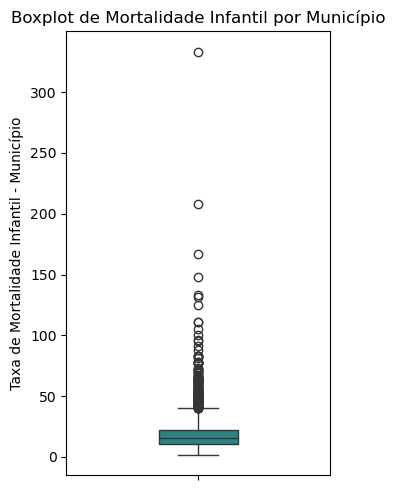

In [87]:
# Boxplot para análise de outliers da taxa de mortalidade infantil
plt.figure(figsize=(3.5,5))
sns.boxplot(df['infant_mortality_rate'], palette='viridis', width=0.3)
plt.title('Boxplot de Mortalidade Infantil por Município')
plt.ylabel('Taxa de Mortalidade Infantil - Município')
plt.tight_layout()
plt.show()

Foram identificados alguns outliers, então o dataframe será filtrado para buscar apenas os municípios onde a taxa de mortalidade infantil se enquadra em um outlier leve (este filtro está automaticamente removendo os registros onde o campo é NaN/null).


Será analisada a distribuição da taxa de mortalidade infantil através do histograma de frequência.

In [88]:
df = df.query('infant_mortality_rate < 50')

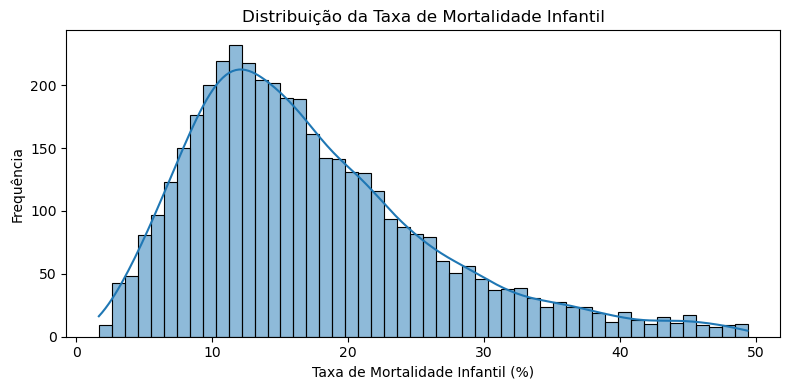

In [89]:
#Plot do histograma
plt.figure(figsize=(8,4))
sns.histplot(df['infant_mortality_rate'], kde=True, bins=50)
plt.xlabel('Taxa de Mortalidade Infantil (%)')
plt.ylabel('Frequência')
plt.title('Distribuição da Taxa de Mortalidade Infantil')
plt.tight_layout()
plt.show()

A distribuição mostra uma assimetria positiva com cauda longa à direita, puxando até 50%. A maioria dos municípios estão se concentrando entre 7 a 20% da taxa.

Os registros nulos das demais features serão preenchidos com a mediana, pois ela é mais resistente a outliers e não puxa a correlação.

In [90]:
df = df.fillna(df.median(numeric_only=True).round(0).astype(int))

## 3. Análise Exploratória dos Dados e Feature Engineering

Nesta etapa, os dados serão analisados por completo na tentativa de identificar padrões e fatores que possuem maior influência na mortalidade infantil, como por exemplo, se o período de estudos da mãe, ou o número de consultas pré-natais, são fatores que possuem algum tipo de correlação com o aumento da mortalidade infantil.

Também será realizada a normalização dos dados, transformando eles em uma escala comparável, já que a discrepância entre o tamanho dos municípios pode enviesar o modelo.

In [91]:
# Separação das features que devem ser multiplicadas por 100 (porcentagem) ou por 1000 (taxa por 1k habitantes)
pct_cols = [    
    "mother_education_0_years",
    "mother_education_1_3_years",
    "mother_education_4_7_years",
    "mother_education_8_11_years",
    "mother_education_12_more_years",
    "mother_age_10_to_19",
    "mother_age_20_to_29",
    "mother_age_30_to_39",
    "mother_age_40_to_49",
    "prenatal_0_visits",
    "prenatal_1_to_3_visits",
    "prenatal_4_to_6_visits",
    "prenatal_7_or_more_visits",
    "birth_weight_less_than_1000g",
    "birth_weight_1000g_to_1499g",
    "birth_weight_1500g_to_2499g",
    "birth_weight_2500g_to_3999g",
    "birth_weight_4000g_or_more",
    "congenital_anomaly_births",
    "gestational_age_less_than_32_weeks",
    "gestational_age_32_to_36_weeks",
    "births_non_white_mothers"
]

cols_to_1000_pop = [
    'primary_care_units'
]

In [92]:
# Criação da função que faz a transformação das features e salva em um novo dataframe
def scale_columns(df, pct_cols, cols_to_1000_pop):
    df[pct_cols] = df[pct_cols].div(df['total_births'], axis=0) * 100
    df[cols_to_1000_pop] = df[cols_to_1000_pop].div(df['total_births'], axis=0) * 1000
    return df.reset_index()

df_cleaned = scale_columns(df.copy(), pct_cols, cols_to_1000_pop)

In [93]:
df_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
index,4156.0,2784.050048,1611.669608,0.0,1396.75,2784.5,4189.5,5562.0
hdi,4156.0,0.654303,0.074684,0.418,0.592,0.656,0.716,1.0
gini,4156.0,0.50373,0.063758,0.0,0.46,0.5,0.54,0.8
average_income_per_capita,4156.0,470.329461,243.909439,95.59,261.7325,421.85,636.6425,2008.98
total_births,4156.0,667.406882,3536.366155,21.0,109.0,222.0,463.0,174265.0
infant_deaths,4156.0,9.469201,43.874274,1.0,2.0,3.0,7.0,2012.0
infant_mortality_rate,4156.0,17.265153,9.068691,1.6502,10.746925,15.3846,21.8069,49.3827
mother_education_0_years,4156.0,3.027831,3.553218,0.032342,0.855669,1.941748,3.932063,63.194444
mother_education_1_3_years,4156.0,9.452897,8.340026,0.201207,3.734968,7.455123,12.824197,80.952381
mother_education_4_7_years,4156.0,32.37431,9.511672,1.355932,25.577317,32.75431,38.888889,83.952255


Existem algumas features que foram convertidas para porcentagem que estão com valor acima de 100%, então, as linhas que ultrapassam esse valor serão removidas.

In [94]:
df_cleaned = df_cleaned[df_cleaned[pct_cols].le(100).all(axis=1)].reset_index(drop=True)

Será criado um mapa de correlação entre a taxa de mortalidade infantil com algumas das features disponíveis, para identificar se há relação entre cada feature individualmente com o target.

Neste caso, será aplicada a correlação de Spearman, já que não há exatamente uma relação linear entre features e target, mas sim uma relação onde ambas as variáveis caminham em uma direção, porém, não necessariamente de forma linear, além do fato de que a correlação de Spearman é muito mais resistentes a outliers, pois utiliza ranking ao invés de valores.

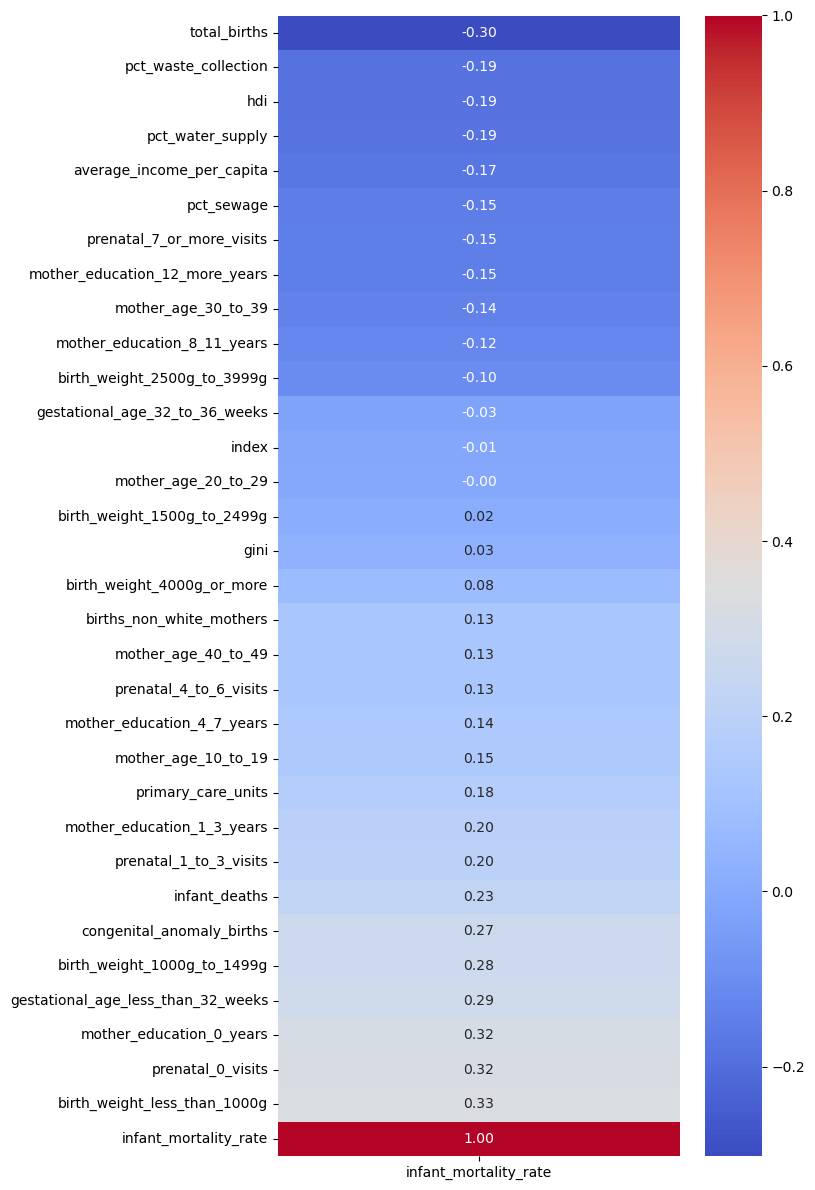

In [95]:
# Criação do mapa de correlação
plt.figure(figsize=(8, 12))
corr = df_cleaned.select_dtypes(include='number').corr(method='spearman')[['infant_mortality_rate']].sort_values(by='infant_mortality_rate')
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()

Acima, é possível identificar que, quanto menor o número de consultas pré-natais, anos de estudo da mãe, peso do recém-nascido e período gestacional, maior a relação positiva entre as variáveis.

O cenário inverso também é válido, quanto maior o número de consultas pré-natais e anos de estudo da mãe, maior a relação negativa entre as variáveis, ou seja, enquanto o número de consultas pré-natais cresce, a taxa de mortalidade diminui.

Também é possível analisar que, existe uma visível correlação negativa entre a taxa de mortalidade infantil e índices socioeconômicos e de infraestrutura, onde, enquanto a taxa de mortalidade infantil cresce, fatores como residências com esgotamento adequado, água tratada por rede geral, coleta de lixo e IDH vão na direção contrária.

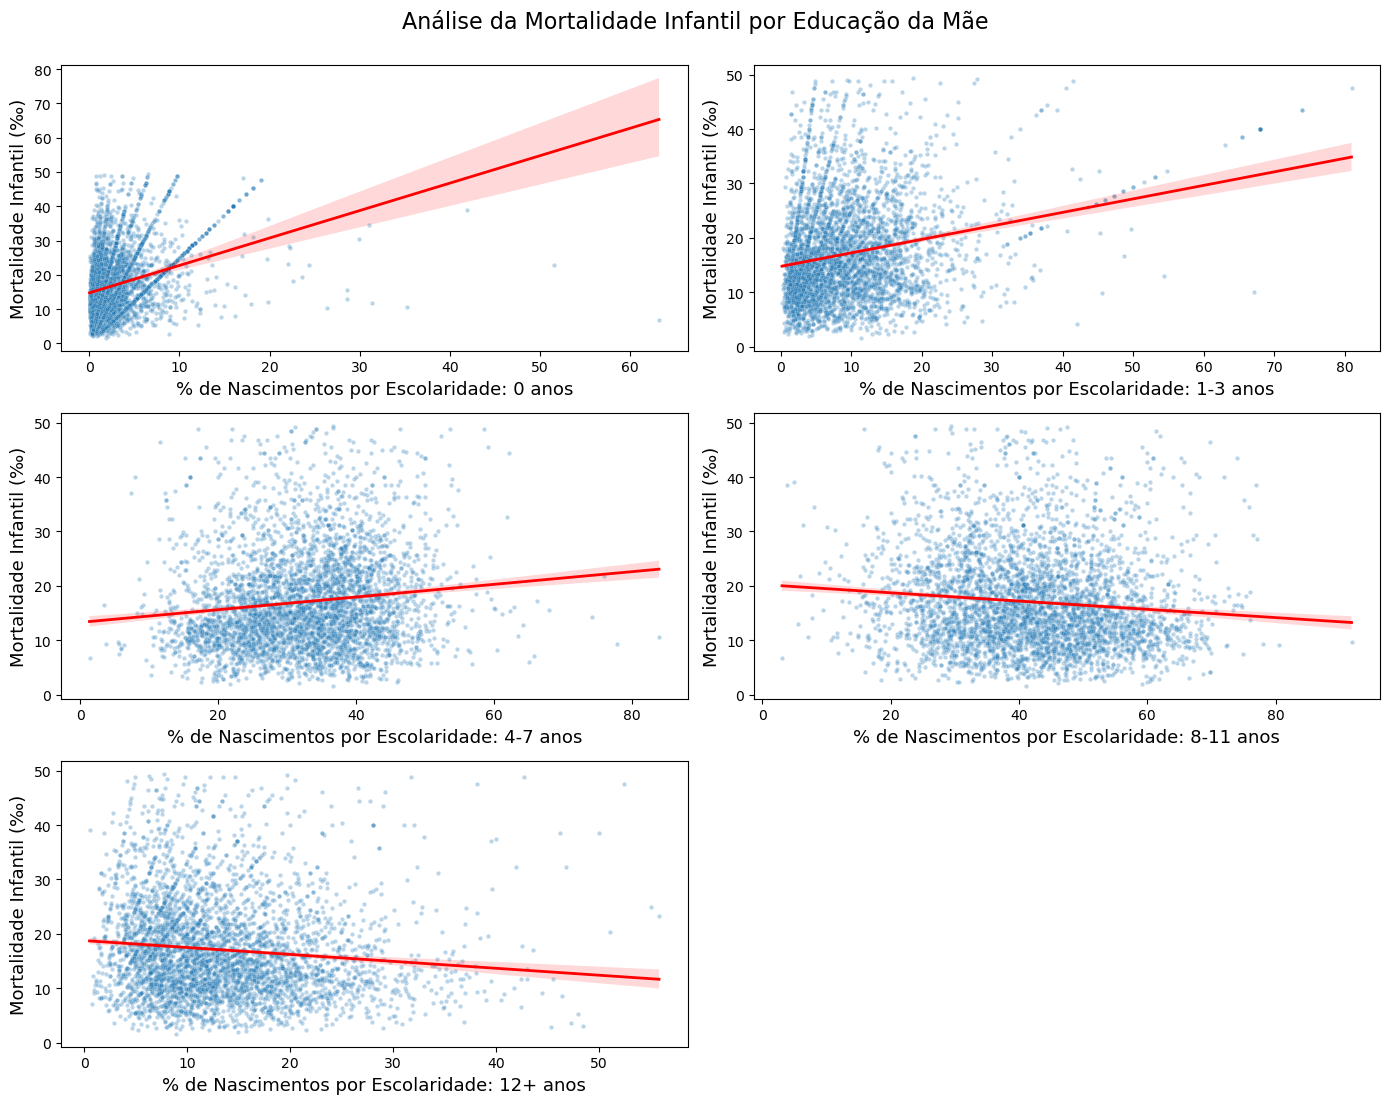

In [96]:
# Separação das features de anos de estudo da mãe
education_cols = {
    '0 anos': 'mother_education_0_years',
    '1-3 anos': 'mother_education_1_3_years',
    '4-7 anos': 'mother_education_4_7_years',
    '8-11 anos': 'mother_education_8_11_years',
    '12+ anos': 'mother_education_12_more_years'
}

# Plot do gráfico de dispersão e da linha de regressão linear sobre os dados
plt.figure(figsize=(14, 11))
plt.suptitle('Análise da Mortalidade Infantil por Educação da Mãe', y=1, size=16)

for i, (label, col) in enumerate(education_cols.items()):
    plt.subplot(3, 2, i+1)
    cols = df_cleaned[col]
    sns.scatterplot(x=cols, y=df_cleaned['infant_mortality_rate'], alpha=0.3, s=10)
    sns.regplot(x=cols, y=df_cleaned['infant_mortality_rate'], scatter=False, color='red', line_kws={'linewidth': 2})
    plt.xlabel(f'% de Nascimentos por Escolaridade: {label}', size=13)
    plt.ylabel('Mortalidade Infantil (‰)', size=13)
plt.tight_layout()
plt.show()

No caso acima, os resultados do gráfico de dispersão e da linha de regressão linear, indicam uma relação negativa entre o período de escolaridade materna e a taxa de mortalidade infantil. É possível avaliar que, os municípios com maior proporção de mães com mais anos de estudo, apresentam menores taxas, indicando que a educação materna é considerada um importante fator protetivo.

Os cinco gráficos em conjunto demonstram uma tendência de queda na taxa de mortalidade a medida em que aumentam os nascimentos com mães com maior grau de escolaridade.

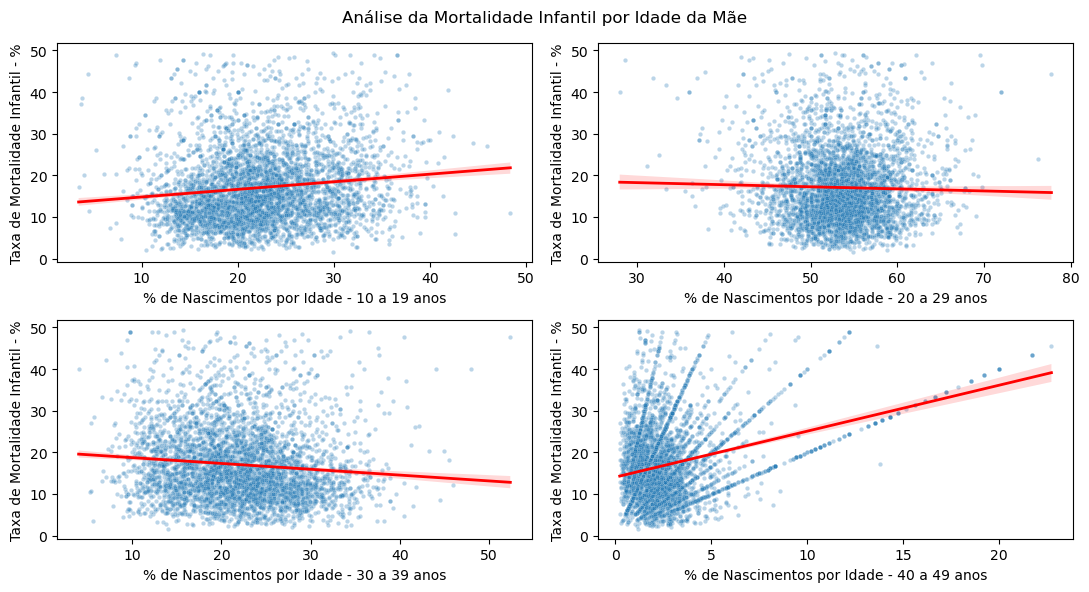

In [97]:
# Separação das features por idade da mãe 
mother_age_cols = {
    'mother_age_10_to_19': '10 a 19 anos',
    'mother_age_20_to_29': '20 a 29 anos',
    'mother_age_30_to_39': '30 a 39 anos',
    'mother_age_40_to_49': '40 a 49 anos',
}

# Plot dos gráficos de dispersão e da linha de regressão linear
plt.figure(figsize=(11, 6))
plt.suptitle('Análise da Mortalidade Infantil por Idade da Mãe', y=0.98)

for i, (col, label) in enumerate(mother_age_cols.items()):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df_cleaned[col], y=df_cleaned['infant_mortality_rate'], alpha=0.3, s=10)
    sns.regplot(scatter=False, color='red', x=df_cleaned[col], y=df_cleaned['infant_mortality_rate'], line_kws={'linewidth': 2})
    plt.ylabel('Taxa de Mortalidade Infantil - %')
    plt.xlabel(f'% de Nascimentos por Idade - {label}')
plt.tight_layout()
plt.show()

No caso acima, na análise do gráfico de dispersão e da linha de regressão linear, é possível analisar que existe uma relação positiva entre a taxa de mortalidade infantil e a proporção de mães que realizaram o parto durante a adolescência ou após os 40 anos. Os municípios com maior incidência de maternidade nessas faixas tendem a apresentar taxas mais elevadas de mortalidade infantil.

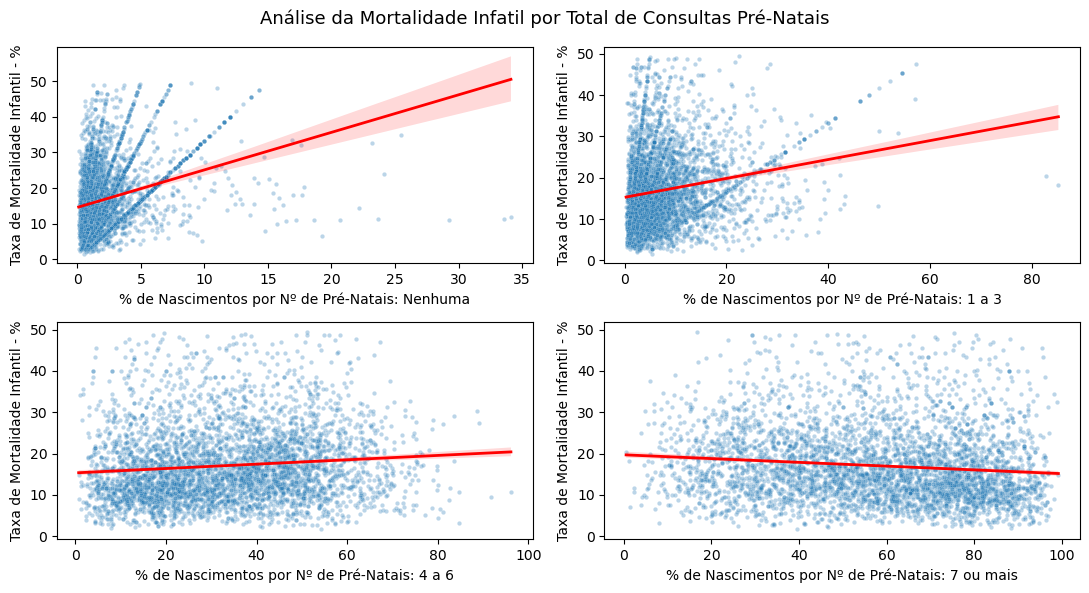

In [98]:
# Separação das features por consultas pré-natais
prenatal_cols = {
    'prenatal_0_visits': 'Nenhuma',
    'prenatal_1_to_3_visits': '1 a 3',
    'prenatal_4_to_6_visits': '4 a 6',
    'prenatal_7_or_more_visits': '7 ou mais'
}

# Plot do gráfico de dispersão e da linha de regressão linear
plt.figure(figsize=(11, 6))
plt.suptitle('Análise da Mortalidade Infatil por Total de Consultas Pré-Natais', y=0.98, size=13)

for i, (col, label) in enumerate(prenatal_cols.items()):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df_cleaned[col], y=df_cleaned['infant_mortality_rate'], alpha=0.3, s=10)
    sns.regplot(x=df_cleaned[col], y=df_cleaned['infant_mortality_rate'], color='red', scatter=False, line_kws={'linewidth': 2})
    plt.xlabel(f'% de Nascimentos por Nº de Pré-Natais: {label}')
    plt.ylabel('Taxa de Mortalidade Infantil - %')
plt.tight_layout()
plt.show()

No caso acima, na análise do gráfico de dispersão e da linha de regressão linear, é possível analisar que existe uma relação positiva entre a taxa de mortalidade infantil e a proporção de mães que realizaram uma quantidade insuficiente de consultas pré-natais. Os municípios com menor ocorrência de consultas pré-natais tendem a apresentar taxas mais elevadas de mortalidade infantil.

Os quatro gráficos em conjunto demonstram uma tendência de queda na taxa de mortalidade a medida que o número de consultas pré-natais aumenta.

In [99]:
# Feature Engineering para adicionar região
region_map = {
    'PA': 'Norte', 'TO': 'Norte', 'AM': 'Norte', 'AC': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'AP': 'Norte',
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'SE': 'Nordeste',
    'AL': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'PB': 'Nordeste',
    'MT': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'DF': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'RS': 'Sul', 'PR': 'Sul', 'SC': 'Sul'
}

df_cleaned['region'] = df_cleaned['state_code'].map(region_map)

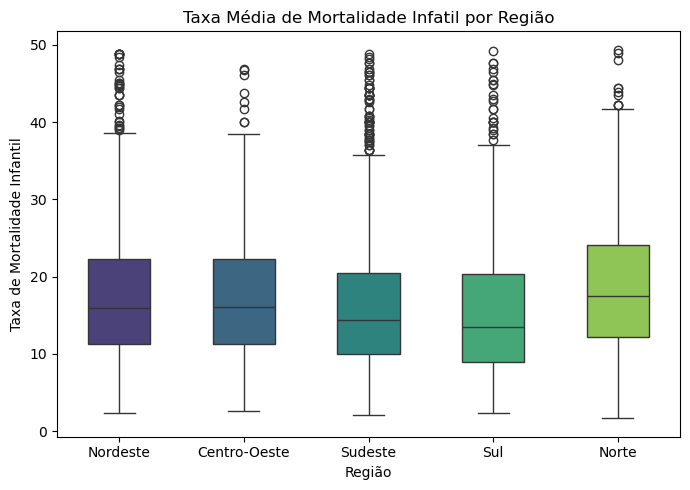

In [100]:
# Plot do boxplot
plt.figure(figsize=(7,5))
sns.boxplot(y=df_cleaned['infant_mortality_rate'], x=df_cleaned['region'], palette='viridis', width=0.5)
plt.title('Taxa Média de Mortalidade Infatil por Região')
plt.xlabel('Região')
plt.ylabel('Taxa de Mortalidade Infantil')
plt.tight_layout()
plt.show()

O boxplot acima mostra como está distribuída a taxa de mortalidade infantil de acordo com cada região. 

É possível identificar com clareza que, a região norte possui maior taxa em todos os índices, 25%, 50% (mediana), 75% e no IQR máximo.

A região sul, ao lado da sudeste, possuem os melhores indicadores, onde, enquanto na região sul os valores Q1 (25%) e a mediana são um pouco menores que na região sudeste, esta possui um IQR máximo um pouco menor que na região sul. 

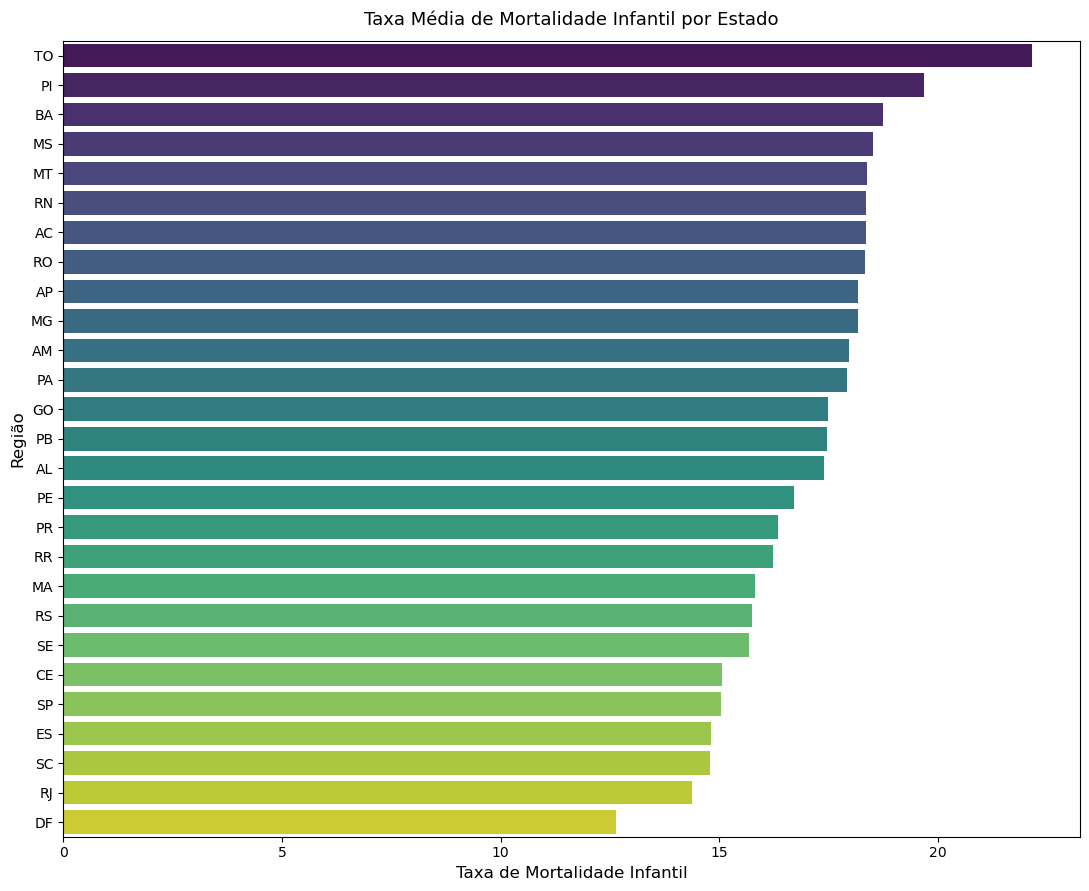

In [101]:
# Ordenação do gráfico do maior para o menor
order = df_cleaned.groupby('state_code')['infant_mortality_rate'].mean().sort_values(ascending=False).index

# Plot do gráfico
plt.figure(figsize=(11, 9))
sns.barplot(x=df_cleaned['infant_mortality_rate'], y=df_cleaned['state_code'], palette='viridis', order=order, errorbar=None)
plt.title('Taxa Média de Mortalidade Infantil por Estado', size=13, y=1.01)
plt.xlabel('Taxa de Mortalidade Infantil', size=12)
plt.ylabel('Região', size=12)
plt.tight_layout()
plt.show()

## Testes de Hipótese

In [102]:
from scipy.stats import shapiro, mannwhitneyu, kruskal

#### 1. Teste Shapiro-Wilk

No primeiro teste de hipótese, nós utilizamos o teste de Shapiro-Wilk para identificar se o nosso alvo (taxa de mortalidade infantil) possui distribuição normal (dados em formato de sino, onde a maioria dos dados se concentra ao redor da média). 

Embora o histograma já tenha sido plotado acima (mostrando que os dados não possuem distribuição normal), precisamos rejeitar a hipótese nula, já que esse teste define quais outros testes de hipótese devemos ou não realizar em seguida.

In [103]:
stat, p_value = shapiro(df_cleaned['infant_mortality_rate'])

print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Distribuição não normal")
else:
    print("Distribuição normal")

P-value: 0.0000
Distribuição não normal


#### 2. Teste Mann-Whitney

O teste de Mann-Whitney compara dois grupos independentes, verificando se existe diferença estatisticamente significativa entre eles. A hipótese nula (H0), mostra que ambos os grupos possuem a mesma distribuição.

Ele é o substituto do teste T, porém, para dados que não possuem distribuição normal.

Neste caso, vamos analisar se há diferença estatisticamente significativa na taxa de mortalidade infantil com base no índice de gini, que determina o nível de desigualdade do município.

In [104]:
high_gini = df_cleaned.query('gini >= 0.52')['infant_mortality_rate']
low_gini = df_cleaned.query('gini <= 0.48')['infant_mortality_rate']

stat, p_value = mannwhitneyu(high_gini, low_gini, alternative='two-sided')

print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Há diferença significativa entre os grupos")
else:
    print("Não há diferença significativa entre os grupos")

P-value: 0.0296
Há diferença significativa entre os grupos


Os resultados mostram que existe diferença estatística significante para rejeitar a hipótese nula, o que significa que, dado os resultados do teste, a diferença observada na taxa de mortalidade infantil não se deve ao acaso, quando comparamos em grupos onde o índice de gini é menor ou igual a 0.48, ou maior ou igual a 0.52.

#### 3. Teste Kruskal-Wallis

O teste Kruskal-Wallis testa se há diferença significativa entre 3 ou mais grupos. A hipótese nula (H0) define que todos os grupos possuem a mesma distribuição.

Ele é o substituto do teste ANOVA, porém, para dados que não possuem distribuição normal.

Neste caso, vamos analisar se há diferença estatisticamente significativa na taxa de mortalidade infantil quando comparamos as diferentes regiões do Brasil. Anteriormente, o boxplot nos mostrou que as regiões norte e sul, apresentaram respectivamente, os piores e melhores indicadores neste sentido. O teste vai rejeitar ou não a hipótese de que as regiões possuem a mesma taxa de mortalidade infantil.

In [105]:
regions = ['Norte','Nordeste','Sul','Sudeste','Centro-Oeste']

groups = []

for region in regions:
    groups.append(df_cleaned.query('region == @region')['infant_mortality_rate'])

stat, p_value = kruskal(*groups)

print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Há diferença significativa entre pelo menos duas regiões")
else:
    print("Não há diferença significativa entre as regiões")

P-value: 0.0000
Há diferença significativa entre pelo menos duas regiões


O resultado do teste rejeita com consistência a hipótese nula, demonstrando que a diferença observada na mortalidade infantil entre as regiões não se dá a uma coincidência.

## Modelo de Machine Learning

### 1. Modelos Baseline

Nessa etapa, serão avaliados diferentes modelos de machine learning, no baseline, sem nenhum tipo de ajuste de hiperparâmetro, para identificar quais algoritmos apresentam melhor desempenho inicial. Aqui, os melhores modelos na métrica R² avançam para a segunda fase, onde serão ajustados.

Em cada célula, terão explicações sobre o passo que está sendo realizado. 

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
import category_encoders as ce
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from tqdm import tqdm
import time
from pprint import pprint
from scipy.stats import randint

In [107]:
# Separação feature e target
# São removidas features desnecessárias e features que causam vazamento de dados
X = df_cleaned.drop(['infant_mortality_rate', 'total_births', 'infant_deaths', 'index', 'city_name'], axis=1)
y = df_cleaned['infant_mortality_rate']

In [108]:
# Separação dos dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)

Pro modelo de regressão, foram removidas algumas features que possuem multicolinearidade perfeita com outras features, causando armadilha de dummy, ou seja, quando somadas (ex: idade da mãe) chegam a 100%, então o modelo não consegue decidir os pesos, porque todas as combinações dão exatamente o mesmo resultado.

Por exemplo, se 3 variáveis $(A, B, C)$ somam 100%, significa dizer que $C = 100 - A - B$

$$
y = w_1 A + w_2 B + w_3 C
$$

Quando adicionamos A e B, o modelo consegue identificar que 100 - A - B é o resultado de C, então ele se torna redundante, já que infinitas combinações acabam no mesmo resultado.

$$
y = w_1 A + w_2 B + w_3 (100 - A - B)
$$


In [109]:
# Drop das features que possuem multicolinearidade perfeita ou não numéricas
num_cols_for_lr = X.drop([
    'mother_age_40_to_49','prenatal_7_or_more_visits', 'region', 'state_code',
    'mother_education_12_more_years','birth_weight_4000g_or_more'], axis=1).columns.tolist()

In [110]:
# Features categóricas
cat_cols = ['state_code', 'region']

In [111]:
# Criação de uma função para buscar a latência de inferência (em ms)
# Executa o predict várias vezes e calcula o tempo médio, que é dividido pelo número de amostrar e convertido pra ms
def get_latency(model, x, runs=10):
    
    times = []
    
    for run in range(runs):
        start = time.time()
        model.predict(x)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    latency = (avg_time / len(x)) * 1000

    return latency

Criação das features de pré-processamento dos modelos:

In [112]:
# A função make_column_selector filtra automaticamente as colunas numéricas, assim evitando retrabalho caso uma nova feature numérica seja adicionada
tree_based_preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', make_column_selector(dtype_include='number'))
])

# O modelo catboost possui codificador próprio, portanto, não utiliza OHE
# Se passarmos OHE pro modelo de catboost, pode ocorrer explosão de dimensionalidade
# Como o transformer retorna um array, o set_output transforma em dataframe, que é utilizado para instanciar o modelo com as features categóricas
# verbose_feature_names_out remove o prefixo que é adicionado ao nome da coluna, para evitar erro ao passar as features categóricas
catboost_preprocessor = ColumnTransformer(transformers=[
    ('cat', 'passthrough', cat_cols),
    ('num', 'passthrough', make_column_selector(dtype_include='number'))
], verbose_feature_names_out=False).set_output(transform="pandas")


# Aplicado StandardScaler no modelo de regressão linear para facilitar a comparação dos coeficientes
# Transforma todas as features em média 0 e desvio padrão 1
lr_preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols_for_lr)
])

Instanciação dos modelos com random_state para garantir reprodutibilidade e comparação entre modelos:

O modelo Ridge foi selecionado porque reduz os coeficientes, já que existem várias features que possuem alta correlação (ex: IDH e Renda per capita).

In [113]:
# Instanciação dos modelos baseline (sem ajuste) que serão treinados
baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=12345),
    "Random Forest": RandomForestRegressor(random_state=12345),
    "XGBoost": XGBRegressor(random_state=12345),
    "CatBoost": CatBoostRegressor(random_state=12345, cat_features=cat_cols),
    "LightGBM": LGBMRegressor(random_state=12345)
}

In [114]:
train_results = {}
baseline_results = {}
baseline_times = {}
predict_times = {}

# Criação do loop que percorre e monta as pipelines para cada tipo de modelo
for name, model in tqdm(baseline_models.items()):
    
    if name in ('Linear Regression', 'Ridge'):
        pipeline = Pipeline(steps=[
            ('preprocessor', lr_preprocessor),
            ('model', model)
        ])
        
    elif name == 'CatBoost':
        pipeline = Pipeline(steps=[
            ('preprocessor', catboost_preprocessor),
            ('model', model)
        ])

    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', tree_based_preprocessor),
            ('model', model)
        ])

    start_time = time.time()

    # Aplicação de validação cruzada via cross_pipeline, que traz tempo de treino e estimadores pra calcular latência de inferência
    # O treino foi dividido em 5 folds diferentes ao invés de um único train test
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring='r2', return_estimator=True, return_train_score=True, n_jobs=-1)

    elapsed_time = time.time() - start_time
    
    train_results[name] = np.mean(scores['train_score'])
    baseline_results[name] = np.mean(scores['test_score'])
    baseline_times[name] = np.mean(scores['fit_time'])

    latencies = []

    # Loop de cada modelo treinado para buscar latência de inferência a partir das features de teste
    for estimator in scores['estimator']:
        latency = get_latency(estimator, X_test)
        latencies.append(latency)
    
    predict_times[name] = np.mean(latencies)

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:54<00:00,  9.14s/it]


In [115]:
# Criação do df que compara os modelos treinados, com nota de treino, teste, tempo para treino e latência de inferência
comparison_df = pd.DataFrame({
    'Model': baseline_models.keys(),
    'Train Score': train_results.values(),
    'Test Score': baseline_results.values(),
    'Fit Time': baseline_times.values(),
    'Predict Time': predict_times.values()
}).sort_values('Test Score', ascending=False).reset_index(drop=True)

comparison_df

,Model,Train Score,Test Score,Fit Time,Predict Time
0,Ridge,0.285375,0.250995,0.019119,0.004509
1,Random Forest,0.894501,0.250489,7.170949,0.021961
2,Linear Regression,0.285392,0.250370,0.019938,0.004497
3,CatBoost,0.878968,0.232487,33.792941,0.005871
4,LightGBM,0.872743,0.215547,3.900584,0.007808
5,XGBoost,0.992308,0.131147,0.618882,0.006767


#### Resultado dos modelos baseline

O baixo resultado na métrica de avaliação pode ser diagnosticado por vários fatores, como o projeto trabalha com dados agregados, aS informações individuais relevantes são perdidas, se a criança estava doente, vacinada, possuía plano de saúde, qualidade do atendimento médico, além de mortes por causas totalmente externas, onde é impossível do modelo conseguir prever, por exemplo, acidente de trânsito, afogamentos, etc.

Sobre os resultados, os modelos de regressão linear conseguiram aprender relativamente com os dados de teste através da métrica R², não caracterizando overfitting. Estes modelos também apresentaram o menor tempo de treinamento e de inferência.

Já nos modelos baseados em árvore, existe um overfitting extremamente agressivo, onde o modelo acabou memorizando ruído e falhando durante o teste. O tempo de treinamento é significativamente maior, principalmente no modelo CatBoost, baseado em gradiente. 

Apenas para explicação, modelos baseados em gradiente criam árvores sequencialmente, onde cada árvore aprende a corrigir os erros da anterior seguindo a direção contrária do gradiente, para minimizar a função de perda:

1. Resíduo = Valor real - Previsão do modelo
$$rm​=y−Fm−1​(x)$$ 

2. Nova previsão = Previsão anterior + Taxa de Aprendizado * Árvore treinada
$$Fm​(x)=Fm−1​(x)+η⋅Tm​(x)$$

### 2. Modelos Ajustados

Nesta etapa, os modelos baseline selecionados vão receber diferentes ajutes de hiperparâmetros aplicando RandomizedSearch, que seleciona aleatoriamente diferentes parâmetros dentro de um range mínimo e máximo, iterando aleatoriamente cada modelo N vezes e salvando seu melhor estimator.

Apesar de um desempenho semelhante ao modelo Ridge, o modelo de regressão linear (LinearRegression) não possui hiperparâmetros, então o mesmo será desconsiderado.

Apenas a título de informação, o modelo Ridge também é regressão linear, porém, diferente da regressão linear tradicional, o Ridge foi feito para minimizar o erro penalizando com maior agressividade grandes coeficientes.

Exemplo: A regressão linear minimiza a função de perda (distância entre valor real e predito) somando todos os exemplos e calculando o erro ao quadrado

$$\min \sum (y_i - \hat{y}_i)^2$$

Já o Ridge, adiciona o hiperparâmetro $\alpha$ que controla quanto a penalidade vai pesar.

$$\alpha \sum \beta_j^2$$

Então, quanto maior o coeficiente, maior a penalidade para o erro.

In [116]:
# Seleção dos hiperparâmetros para tuning dos modelos
# No Random Forest, estes valores foram selecionados propositadamente para tentar reduzir o overfitting extremo
params = {
    'Ridge': {
        'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    
    'Random Forest': {
        'model__n_estimators': randint(200, 1000),
        'model__max_depth': randint(3, 8),
        'model__min_samples_split': randint(10, 20),
        'model__min_samples_leaf': randint(10, 20) 
    },
}

# Instanciação dos modelos
tuned_models = {
    'Ridge': Ridge(random_state=12345),
    'Random Forest': RandomForestRegressor(random_state=12345),
}

tuned_models_result = {}

# Loop para percorrer todos os modelos com lógica booleana para selecionar o pré-processamento correto.
for name, model in tqdm(tuned_models.items()):
    
    if name == 'Ridge':
        pipeline = Pipeline(steps=[
            ('preprocessor', lr_preprocessor),
            ('model', model)
        ])
        
    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', tree_based_preprocessor),
            ('model', model)
        ])


    # Randomização para busca dos melhores hiperparâmetros
    # Aqui, são realizadas 50 iterações para cada modelo
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params[name],
        cv=5,
        n_iter=50,
        scoring='r2',
        random_state=12345,
        n_jobs=-1  
    )

    search.fit(X_train, y_train)

    # Armazenamento dos resultados e parâmetros na variável
    tuned_models_result[name] = {
        'r2': search.best_score_,
        'best_params': search.best_params_,
        'best_estimator': search.best_estimator_
    }

100%|███████████████████████████████████████████████████████████████████████████████████| 2/2 [06:27<00:00, 193.93s/it]


In [118]:
# Loop para comparar ambos os modelos ajustados
for name, result in tuned_models_result.items():
    estimator = result['best_estimator']
    
    train_r2 = estimator.score(X_train, y_train)
    test_r2  = estimator.score(X_test, y_test)
    
    print(f"\n{name}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Gap: {train_r2 - test_r2:.4f}")
    print(f"Params: {result['best_params']}")


Ridge
Train R²: 0.2786
Test R²: 0.2586
Gap: 0.0200
Params: {'model__alpha': 100}

Random Forest
Train R²: 0.4395
Test R²: 0.2668
Gap: 0.1728
Params: {'model__max_depth': 7, 'model__min_samples_leaf': 11, 'model__min_samples_split': 19, 'model__n_estimators': 372}


#### Resultado dos modelos ajustados

O processo de tuning conseguiu reduzir o overfitting extremo do Random Forest, reduzindo o gap entre treino e teste para 0.17, porém indicando que o modelo continua aprendendo ruído nos dados de treino. Este modelo apresenta um resultado de teste levemente superior.

Já o modelo Ridge possui uma capacidade de generalização muito melhor, além do fato de possuir menor tempo de treino, inferência e ser mais interpretável que o modelo Random Forest, embora tenha tido um resultado pouco inferior nos dados de teste.

Então, o Ridge será o modelo selecionado para fine-tuning, com o objetivo de extrair o máximo de performance.

### 3. Modelo Final

In [119]:
# Seleção dos hiperparâmetros
fine_tune_params = {
    'model__alpha': [80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 150, 200]
} 

# Montagem da pipeline
fine_tune_pipeline = Pipeline(steps=[
    ('preprocessor', lr_preprocessor),
    ('model', Ridge(random_state=12345))
])

# Utilização de gridsearch, que percorre todos os hiperparâmetros selecionados.
# Difere do randomsearch, que seleciona aleatoriamente diferentes valores N vezes.
fine_search = GridSearchCV(
    estimator=fine_tune_pipeline,
    param_grid=fine_tune_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Treina o modelo
fine_search.fit(X_train, y_train)

# Salva o modelo com o melhor tuning
best_model = fine_search.best_estimator_

# Predict do modelo
y_pred_train = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

# Buscar tempo de inferência
fine_tune_latency = get_latency(fine_search.best_estimator_, X_test)

print(f"Melhor alpha: {fine_search.best_params_}")
print(f"R²: {fine_search.best_score_:.4f}")
print(f"Tempo de inferência: {fine_tune_latency:.4f}ms")

Melhor alpha: {'model__alpha': 150}
R²: 0.2591
Tempo de inferência: 0.0035ms


#### Resultado Final

O processo de seleção de modelos que utilizo é dividido em três etapas diferentes. O mesmo foi aplicado neste projeto, vou explicar a metodologia:

Na primeira etapa, eu seleciono vários modelos que se adequam ao projeto, e treino todos sem nenhum tipo de ajuste de hiperparâmetro. Aqui, vejo se há underfitting/overfitting, tempo de treino, tempo de inferência e, principalmente, o score do teste na métrica alvo. São selecionados os melhores modelos que apresentam resultados semelhantes para a segunda etapa.

Na segunda etapa, os melhores modelos passam por ajustes de hiperparâmetros, que são selecionados e preenchidos com intervalos de acordo com o resultado da etapa anterior, por exemplo, min_samples_leaf do modelo Random Forest, que define um número mínimo de amostrar que uma folha deve ter (nó é uma pergunta, e folha uma resposta), possui o valor default 1, e, aumentar esse valor reduz overfitting, por esta razão, selecionamos valores em intervalos de 10 a 20. Aqui, nesta etapa, selecionamos aquele que apresentou o melhor resultado e passamos para o fine-tuning (ajuste fino) do modelo.

Na terceira e última etapa, o melhor modelo é novamente ajustado, com hiperparâmetros mais finos, bem mais próximos ao resultado do best_params (que traz os hiperparâmetros com melhor resultado). Aqui tem um detalhe, quando eu aplico randomizedsearch no treino, eu aumento o número de iterações.

Nesse processo, conseguimos trazer mais eficiência computacional descartando modelos ruins na primeira etapa e maior rastreabilidade, entendendo como os modelos se comporaram após ajustes.

### 4. Avaliação

In [123]:
import shap
from sklearn.dummy import DummyRegressor

#### SHAP

O SHAP é um método para entender como cada coeficiente influencia no resultado previsto, em vez de fornecer apenas uma previsão final, ele mostra quanto cada variável contribuiu para aumentar ou diminuir esse valor. Quando o plot é positivo, significa que aquela variável aumentou a previsão, e, quando é negativo, significa que reduziu a previsão.

In [124]:
# Busca o modelo final e a pipeline
ridge = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

# Aplica preprocessamento no conjunto de treino
X_train_transformed = preprocessor.transform(X_train)

# Cria e calcula o shap para cada amostra
explainer = shap.LinearExplainer(ridge, X_train_transformed)
shap_values = explainer.shap_values(X_train_transformed)

# Armazena nomes e índices das features numéricas
feature_names = []
num_index = []

# Busca o nome de todas as features dentro da pipeline
all_features = preprocessor.get_feature_names_out()

# Loop para percorrer todas as features, selecionar apenas as não regionais e limpar o nome da feature
for i, feature in enumerate(all_features):
    if not feature.startswith('ohe__'):
        feature_names.append(
            feature.replace('num__', '').replace('_', ' ')
        )
        num_index.append(i)

Cada linha representa uma feature com um violin plot, onde cada ponto representa um dado, neste caso um município, e a posição no eixo X indica o impacto da variável na previsão. Caso os pontos vermelhos estejam concentrados à direita, isso indica que os valores altos dessa variável aumentam a previsão, por exemplo, o nascimento de crianças com anomalia congênita possuem essa característica, indicando que este é um fator que possui alta influência na mortalidade infantil. Outra característica é a largura do violino, quanto maior a largura, maior a concentração de dados (municípios) naquele ponto.

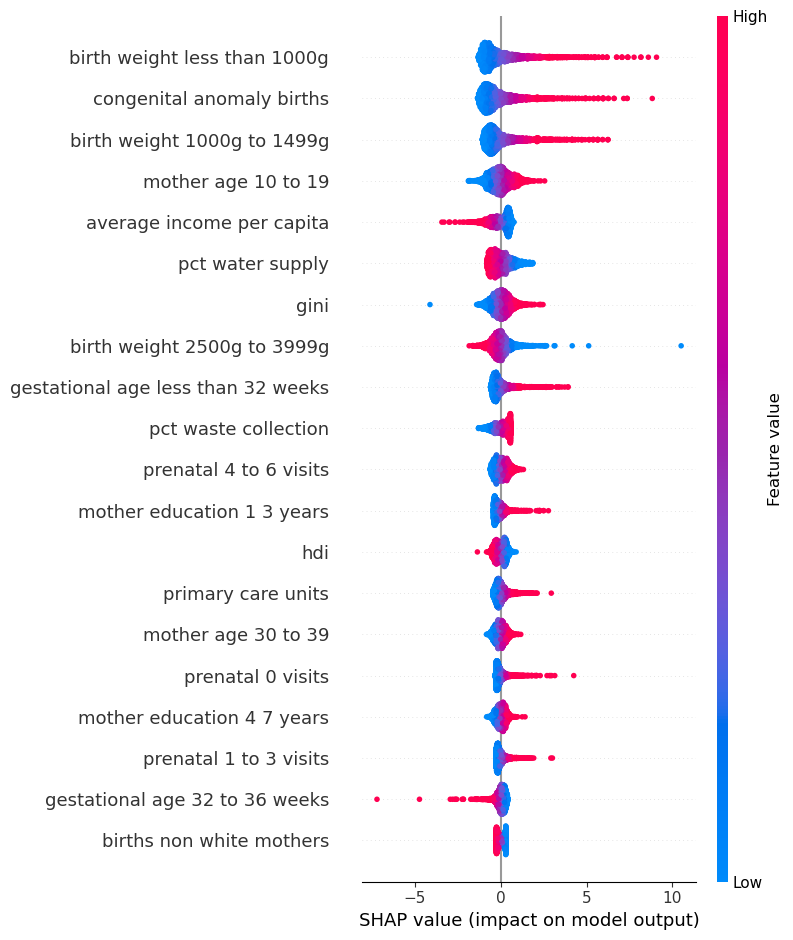

In [125]:
# Busca apenas os índices e valores das features numéricas
X_num = X_train_transformed[:, num_index]
shap_num = shap_values[:, num_index]

# Plot do SHAP
shap.summary_plot(shap_num, X_num, feature_names=feature_names)

De acordo com o método SHAP, as features que mais influenciam na taxa de mortalidade infantil são: 

1. Nascimentos com menos de 1kg;
2. Nascimentos com anomalia congênita;
3. Nascimentos com peso entre 1kg e 1.5kg;
4. Idade da mãe entre 10 a 19 anos;
5. Renda média per capita.

#### Comparação com Dummy

Neste caso, será comparada a previsão do modelo (Métrica RMSE) com um modelo dummy, que simplesmente chuta a média.

In [126]:
# Criação do modelo dummy que chuta a média
dummy = DummyRegressor(strategy='mean').fit(X_train, y_train)

# RMSE do dummy e do ridge
rmse_dummy = np.sqrt(mean_squared_error(y_test, dummy.predict(X_test)))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE Dummy (Média): {rmse_dummy:.2f}") 
print(f"RMSE Ridge: {rmse_ridge:.2f}")
print(f"Ganho: {(1 - rmse_ridge/rmse_dummy)*100:.1f}%")

RMSE Dummy (Média): 8.80
RMSE Ridge: 7.57
Ganho: 14.0%


O modelo conseguiu adquirir uma melhoria modesta de apenas 14% em relação a um modelo dummy, que chuta o valor médio.

#### Avaliação de Overfitting

In [127]:
# Comparação do score do modelo nos dados de treino e teste para identificação de overfitting
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)

print(f"Score no Treino: {r2_train:.4f}")
print(f"Score no Teste: {r2_test:.4f}")

Score no Treino: 0.2772
Score no Teste: 0.2589


O modelo apresentou ótima capacidade de generalização, demonstrando desempenho semelhante nos dados de treino e teste.

#### Distribuição de Resíduos

O resíduo é o resultado da subtração do valor real pelo valor predito.

Neste caso, vamos exibir um histograma para analisar como os resíduos estão distribuídos.

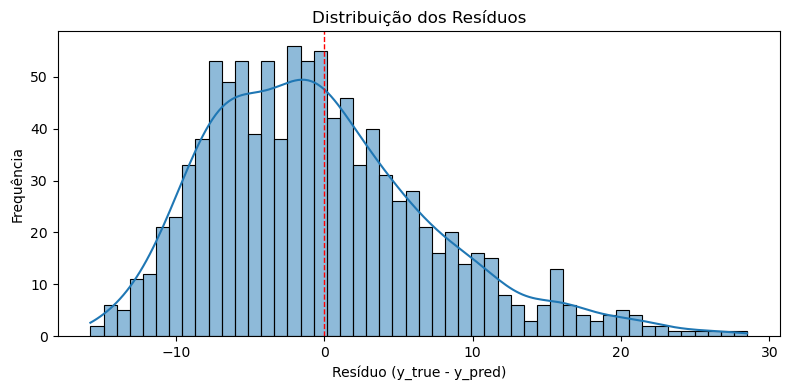

In [128]:
residual = y_test.values - y_pred
    
plt.figure(figsize=(8,4))
sns.histplot(residual, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (y_true - y_pred)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

A maioria dos municípios possui erro pequeno, com o modelo acertando de forma razoável. Os resíduos mostram uma distribuição assimétrica à direita, da mesma forma que o histograma de distribuição do nosso target (Taxa de Mortalidade Infantil), com o modelo subestimando municípios com a mortalidade infantil muito alta, mesmo tratando outliers.

## Conclusão Final

O projeto teve como objetivo identificar fatores associados à mortalidade infantil nos municípios brasileiros a partir de dados do censo de 2010, combinando análise exploratória, testes estatísticos e modelagem preditiva.

A análise exploratória confirmou diferenças estatisticamente significativas na mortalidade infantil entre regiões e entre municípios com diferentes níveis de desigualdade. O modelo final (Ridge) conseguiu aprender de forma razoável, superando o baseline em 14% no RMSE e mantendo boa capacidade de generalização.

O R² de 0.26, no entanto, revela que grande parte da variabilidade da mortalidade infantil permanece não explicada pelo modelo, já que dados agregados por município perdem informações individuais relevantes sobre cada gestação, mãe e criança, como qualidade real da assistência ao parto, ausência de plano de saúde, renda média familiar, etc. Também há impacto no resultado devido à variáveis ausentes de relevância totalmente causal, como cobertura vacinal e óbitos por causas externas, como afogamento e acidente de trânsito, além da própria assimetria do target, que dificulta a previsão dos casos extremos, que são justamente os de maior vulnerabilidade.

Durante o desenvolvimento, foram utilizadas diversas tentativas para melhorar a performance do modelo. As features foram convertidas em taxas comparáveis para evitar efeito de escala entre municípios de tamanhos diferentes, nulos foram preenchidos com mediana por ser mais resistente à outliers, engenharia de features, foram removidas features que causariam multicolinearidade perfeita em modelos lineares, avaliação de diversos modelos baseline com validação cruzada e seleção dos melhores modelos para fase de tuning.

Todo processo realizado demonstra que os resultados não são expressivos por duas razões, uma se dá pelo fato de que o target é simplesmente uma variável muito volátil e complexa de se modelar, e outra de que o modelo atingiu o teto com os dados que estavam à disposição, e um ganho mais expressivo dependeria de novas features, não de mais tuning.

O modelo está estável, interpretável e com ganho sobre o baseline.